Task 1 — Classical Perceptron Training 

AND: epochs = 6 w = [1.  0.5] b = -1.0
AND: mistakes per epoch = [1, 3, 3, 2, 1, 0]
AND: final predictions  = [0 0 0 1]
XOR: epochs = 20 w = [-0.5  0. ] b = 0.5
XOR: mistakes per epoch = [2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
XOR: final predictions  = [1 1 0 0]
AND wrong predictions:
XOR wrong predictions:
input = [0. 0.] target = 0 prediction = 1
input = [1. 0.] target = 1 prediction = 0
Task 1 OK


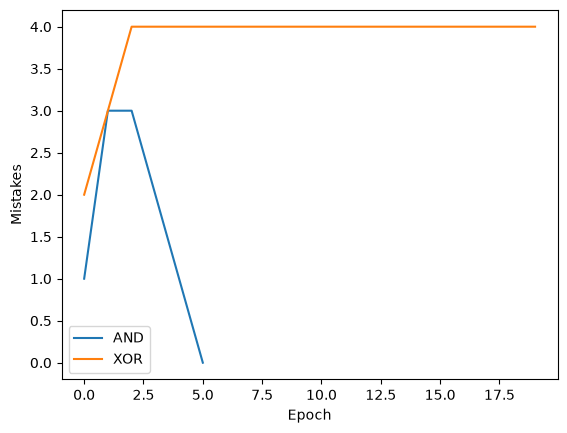

In [23]:
import numpy as np 
import matplotlib.pyplot as plt 
 
X = np.array([ 
    [0.0, 0.0], 
    [0.0, 1.0], 
    [1.0, 0.0], 
    [1.0, 1.0], 
]) 
 
y_and = np.array([0, 0, 0, 1]) 
y_xor = np.array([0, 1, 1, 0]) 
 
 
def predict(X, w, b): 
    # TODO: apply the strict threshold, return 0/1 labels 
    scores = np.dot(X, w) + b
    return (scores > 0).astype(int)
 
 
def train_perceptron(X, y, eta=0.5, max_epochs=20): 
 
    w = np.zeros(2) 
    b = 0.0 
 
    mistakes_per_epoch = [] 
 
    for epoch in range(max_epochs): 
 
        mistakes = 0 
 
        for i in range(len(X)): 
 
            # TODO: predict BEFORE the update 
            # TODO: count a mistake if the prediction is wrong 
            # TODO: apply the perceptron update for this example 
            pred = predict(X[i], w, b)
            error = y[i] - pred
            
            if pred != y[i]:
                mistakes += 1

            w = w + eta * error * X[i]
            b = b + eta * error 
 
        mistakes_per_epoch.append(mistakes) 
 
        # TODO: stop early if this epoch had zero mistakes 
        if mistakes == 0:
            break
 
    return w, b, mistakes_per_epoch 
 
 
w_and, b_and, hist_and = train_perceptron(X, y_and) 
w_xor, b_xor, hist_xor = train_perceptron(X, y_xor) 
 
print("AND: epochs =", len(hist_and), "w =", w_and, "b =", b_and) 
print("AND: mistakes per epoch =", hist_and) 
print("AND: final predictions  =", predict(X, w_and, b_and)) 
 
print("XOR: epochs =", len(hist_xor), "w =", w_xor, "b =", b_xor) 
print("XOR: mistakes per epoch =", hist_xor) 
print("XOR: final predictions  =", predict(X, w_xor, b_xor)) 
 
# TODO: plot mistakes per epoch for both runs 
plt.plot(hist_and, label="AND")
plt.plot(hist_xor, label="XOR")
plt.xlabel("Epoch")
plt.ylabel("Mistakes")
plt.legend()

# TODO: report wrong predictions of each FINAL model 
and_preds = predict(X, w_and, b_and)
xor_preds = predict(X, w_xor, b_xor)

print("AND wrong predictions:")
for x_i, target, pred in zip(X, y_and, and_preds):
    if pred != target:
        print("input =", x_i, "target =", target, "prediction =", pred)

print("XOR wrong predictions:")
for x_i, target, pred in zip(X, y_xor, xor_preds):
    if pred != target:
        print("input =", x_i, "target =", target, "prediction =", pred)
        
assert np.all(predict(X, w_and, b_and) == y_and) 
 
print("Task 1 OK") 

Task 2 — Hidden Unit over a Batch 

In [24]:
x = np.array([0.5, 1.0, 1.5, 2.0]) 
y = np.array([2.0, 3.0, 4.0, 5.0])

params0 = np.array([0.5, 0.5, 1.0, 0.0]) 
# Fixed parameter order: [w1, b1, w2, b2] 

Part A — Forward Pass 

In [30]:
def forward(params, x): 
 
    w1, b1, w2, b2 = params 
 
    z1 = np.dot(w1, x) + b1      # TODO 
    h = np.maximum(0, z1)       # TODO 
    yhat = np.dot(w2, h) + b2    # TODO 
 
    return z1, h, yhat 
 
 
def batch_loss(params, x, y): 
 
    z1, h, yhat = forward(params, x) 
 
    assert yhat.shape == y.shape 
 
    return yhat - y    # TODO 

print(forward(params0, x))

(array([0.75, 1.  , 1.25, 1.5 ]), array([0.75, 1.  , 1.25, 1.5 ]), array([0.75, 1.  , 1.25, 1.5 ]))


Part B — Manual Gradients 

z1 = w1x+b -> h = ReLU(z1)  ->  yhat = w2h+b2 ->  L = 1/N * (yhat-y)**2

In [26]:
def batch_gradients(params, x, y): 
 
    w1, b1, w2, b2 = params 
 
    z1, h, yhat = forward(params, x) 
 
    N = len(x) 
 
    g_yhat = 2*(yhat-y)/N  # TODO 
    g_w2 = np.sum(g_yhat * h)    # TODO 
    g_b2 = np.sum(g_yhat)    # TODO 
    g_h = g_yhat * w2     # TODO 
    g_z1 = g_h*(z1 > 0).astype(float)    # TODO 
    g_w1 = np.sum(g_z1*x)    # TODO 
    g_b1 = np.sum(g_z1)    # TODO 
 
    return np.array([g_w1, g_b1, g_w2, g_b2]) 

Task 3 — Gradient Checking and Training 

Part A — Numerical Gradient Check 

In [ ]:
def batch_loss(params, x, y):
    z1, h, yhat = forward(params, x)

    assert yhat.shape == y.shape

    return np.mean((yhat - y)**2)

def numerical_gradient(fn, params, eps=1e-5): 
 
    gradient = np.zeros_like(params, dtype=float) 
 
    for j in range(len(params)): 
 
        plus = params.copy() 
        minus = params.copy() 
 
        # TODO: perturb coordinate j in each copy 
        # TODO: assign the central-difference estimate 
 
        plus[j] += eps
        minus[j] -= eps

        gradient[j] = (fn(plus) - fn(minus)) / (2 * eps)
 
 
    return gradient 
 
analytic = batch_gradients(params0, x, y) 
 
numeric = numerical_gradient( 
    lambda p: batch_loss(p, x, y), params0 
) 
 
print("analytic:", analytic) 
print("numeric :", numeric) 
print("max absolute difference:", np.max(np.abs(analytic - numeric))) 
 
assert np.max(np.abs(analytic - numeric)) < 1e-6 
 
print("Task 3A OK") 

analytic: [-6.875  -4.75   -5.8125 -4.75  ]
numeric : [-6.875  -4.75   -5.8125 -4.75  ]
max absolute difference: 8.662937034387141e-11
Task 3A OK


Part B — One Update, Then a Training Loop 

In [33]:
params = params0.copy() 
eta = 0.01 
 
loss_history = [batch_loss(params, x, y)] 
 
for step in range(200): 
 
    gradients = batch_gradients(params, x, y)   # TODO: all gradients at the current params 
    params = params - eta * gradients      # TODO: update the entire vector 
 
    loss_history.append(batch_loss(params, x, y)) 

print("final params:", params) 
print("final loss  :", loss_history[-1]) 
 
assert len(loss_history) == 201 
assert loss_history[-1] < loss_history[0] 
 
print("Task 3B OK") 

final params: [1.21710839 0.65019193 1.54577988 0.1613669 ]
final loss  : 0.004726306469450738
Task 3B OK
